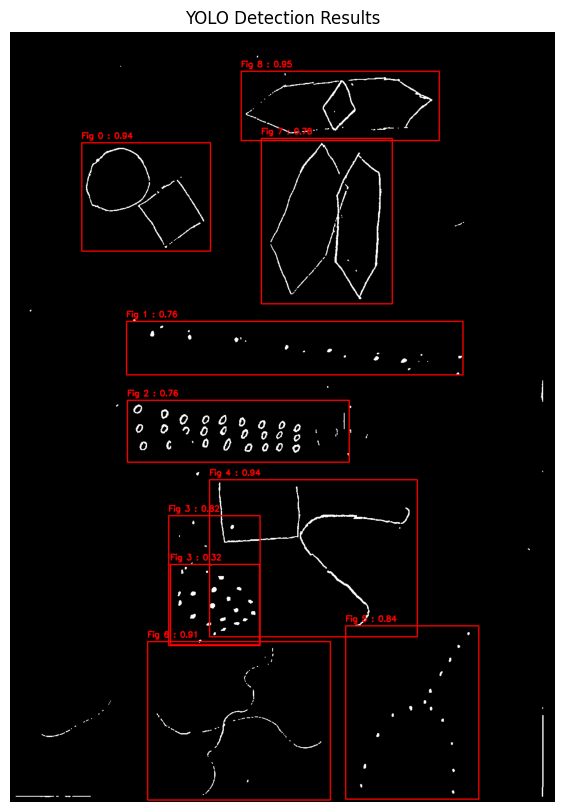

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLO model

model_path = r"E:\FCAI\third year\cog\bender project\myProject\best.pt"
model = YOLO(model_path)
image_path = r"E:\FCAI\third year\cog\bender project\myProject\Preprocessed\1.jpg"

# Run prediction

results = model.predict(
    source=image_path,
    conf=0.3,
    verbose=False
)

# first image result
result = results[0]

# Read image

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw detections

boxes = result.boxes.xyxy.cpu().numpy()
classes = result.boxes.cls.cpu().numpy()
scores = result.boxes.conf.cpu().numpy()

for box, cls, score in zip(boxes, classes, scores):

    x1, y1, x2, y2 = map(int, box)

    # draw rectangle
    cv2.rectangle(
        img_rgb,
        (x1, y1),
        (x2, y2),
        (255,0,0),
        2
    )

    # label text
    text = f"Fig {int(cls)} : {score:.2f}"

    cv2.putText(
        img_rgb,
        text,
        (x1, y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,0,0),
        2
    )
# Show image

plt.figure(figsize=(14,10))

plt.imshow(img_rgb)

plt.axis("off")

plt.title("YOLO Detection Results")

plt.show()

In [2]:
import numpy as np
import math


def extract_sequence_features(boxes, img_shape):

    # Extract Centers

    centers = []

    for box in boxes:

        x1, y1, x2, y2 = map(int, box)

        center_x = (x1 + x2) // 2
        center_y = (y1 + y2) // 2

        centers.append((center_x, center_y))
    
    #  Sort Centers
    centers = sorted(centers, key=lambda p: p[1])

    # SAFETY CHECK
    if len(centers) < 2:

        return {

            "num_figures": len(centers),

            "avg_jump": 0,
            "jump_std": 0,

            "direction_changes": 0,

            "angle_std": 0,

            "spread_x": 0,
            "spread_y": 0,

            "alignment_x": 0,
            "alignment_y": 0,

            "left_margin": 0,
            "right_margin": 0,
            "top_margin": 0,
            "bottom_margin": 0,

            "mean_x": 0,
            "mean_y": 0
        }

     # FEATURE 1
    # Number of Figures
    num_figures = len(centers)
  
    # FEATURE 2
    # Jump Distances
    jump_distances = []

    for i in range(len(centers) - 1):

        x1, y1 = centers[i]
        x2, y2 = centers[i + 1]

        dist = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

        jump_distances.append(dist)

    avg_jump = np.mean(jump_distances)
    jump_std = np.std(jump_distances)

    # FEATURE 3
    # Directions
    directions = []

    for i in range(len(centers) - 1):

        x1, y1 = centers[i]
        x2, y2 = centers[i + 1]

        dx = x2 - x1
        dy = y2 - y1

        directions.append((dx, dy))

    # FEATURE 4
    # Direction Changes
    direction_changes = 0

    for i in range(len(directions) - 1):

        dx1, dy1 = directions[i]
        dx2, dy2 = directions[i + 1]

        # horizontal direction change
        if (dx1 > 0 and dx2 < 0) or (dx1 < 0 and dx2 > 0):

            direction_changes += 1

    # FEATURE 5
    # Angle Variability

    angles = []

    for dx, dy in directions:

        angle = math.atan2(dy, dx)

        angles.append(angle)

    angle_std = np.std(angles)

    # FEATURE 6
    # Spatial Spread
    xs = [p[0] for p in centers]
    ys = [p[1] for p in centers]

    spread_x = max(xs) - min(xs)
    spread_y = max(ys) - min(ys)

   
    # FEATURE 7
    # Alignment Score
    alignment_x = np.std(xs)
    alignment_y = np.std(ys)

   
    # FEATURE 8
    # Margin Usage
    img_h, img_w = img_shape[:2]

    left_margin = min(xs)

    right_margin = img_w - max(xs)

    top_margin = min(ys)

    bottom_margin = img_h - max(ys)


    # FEATURE 9
    # Drawing Position
    mean_x = np.mean(xs)
    mean_y = np.mean(ys)

    # RETURN FEATURES
    return {

        "num_figures": num_figures,

        "avg_jump": avg_jump,
        "jump_std": jump_std,

        "direction_changes": direction_changes,

        "angle_std": angle_std,

        "spread_x": spread_x,
        "spread_y": spread_y,

        "alignment_x": alignment_x,
        "alignment_y": alignment_y,

        "left_margin": left_margin,
        "right_margin": right_margin,

        "top_margin": top_margin,
        "bottom_margin": bottom_margin,

        "mean_x": mean_x,
        "mean_y": mean_y
    }

In [3]:
import os 
import cv2 
import pandas as pd 

#read labels from excel
bender_test = r"E:\FCAI\third year\cog\bender project\myProject\bender.csv"
df  = pd.read_csv(bender_test)

#dataset
folder_path = r"E:\FCAI\third year\cog\bender project\myProject\Preprocessed"
all_data = []
for filename in os.listdir(folder_path):
    if filename.lower().endswith((".png", ".jpg",".jpeg")):
        image_path = os.path.join(folder_path, filename) 
        img = cv2.imread(image_path)
        if img is None:
            continue

        results = model.predict(
        source=image_path,
        conf=0.3,
        verbose=False   
            )

        result = results[0]

        boxes = result.boxes.xyxy.cpu().numpy()

        features = extract_sequence_features(
            boxes,
            img.shape
        )
        case_number = int(os.path.splitext(filename)[0])
        row = df[df["Case Number"] == case_number]
        if not row.empty:

            label = row["Sequence"].values[0]

            # add info
            features["label"] = label
            features["image"] = filename

            # save row
            all_data.append(features)

# build dataframe
dataset = pd.DataFrame(all_data)

# show dataset
print(dataset.head())

# save csv
dataset.to_csv("sequence_features_dataset.csv", index=False)



   num_figures    avg_jump    jump_std  direction_changes  angle_std  \
0           10  328.823307  136.156810                  6   0.998791   
1           13  351.926599  218.850411                 10   1.127273   
2           10  254.681118  156.755916                  5   0.776725   
3           11  380.624382  214.517086                  6   1.108930   
4            9  287.918207  131.664274                  4   0.978479   

   spread_x  spread_y  alignment_x  alignment_y  left_margin  right_margin  \
0       606      1401   167.550739   478.282385          309           326   
1       816      1390   206.788089   373.843162          240           185   
2       536      1373   139.885811   434.687888          185           520   
3       781      1150   244.186996   381.724188          238           222   
4       830      1018   257.122587   326.145843          125           286   

   top_margin  bottom_margin      mean_x      mean_y                  label  \
0         168      

In [4]:
print(dataset.describe())

       num_figures    avg_jump    jump_std  direction_changes  angle_std  \
count    89.000000   89.000000   89.000000          89.000000  89.000000   
mean      9.808989  402.489155  164.695896           5.696629   1.118048   
std       1.126907  113.824377   58.480014           1.525574   0.204707   
min       8.000000  171.559353   48.660955           2.000000   0.290836   
25%       9.000000  327.259991  129.472166           5.000000   1.031485   
50%      10.000000  389.225712  160.112487           6.000000   1.159052   
75%      10.000000  464.975331  209.086707           7.000000   1.255373   
max      14.000000  769.751384  316.509318          10.000000   1.431863   

          spread_x     spread_y  alignment_x  alignment_y  left_margin  \
count    89.000000    89.000000    89.000000    89.000000    89.000000   
mean    708.337079  1138.561798   241.890663   365.132885   268.202247   
std     206.528665   253.759816    76.610739    80.331920   118.860134   
min     110.000000 

In [5]:
print(dataset["label"].value_counts())

label
Disorganized Sequence    42
Organized Sequence       26
Confused Sequence        12
Fixed Sequence            9
Name: count, dtype: int64


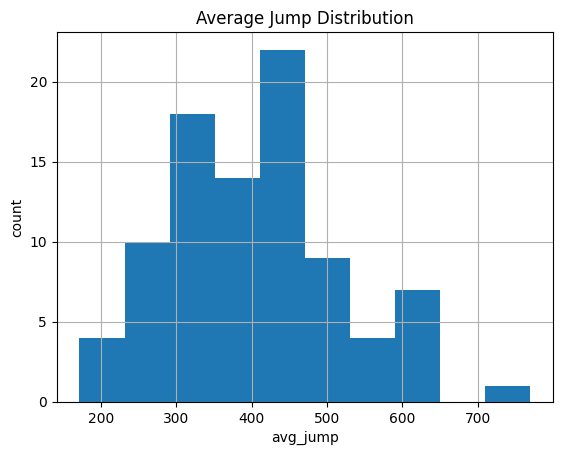

In [6]:
import matplotlib.pyplot as plt

dataset["avg_jump"].hist()

plt.title("Average Jump Distribution")

plt.xlabel("avg_jump")

plt.ylabel("count")

plt.show()

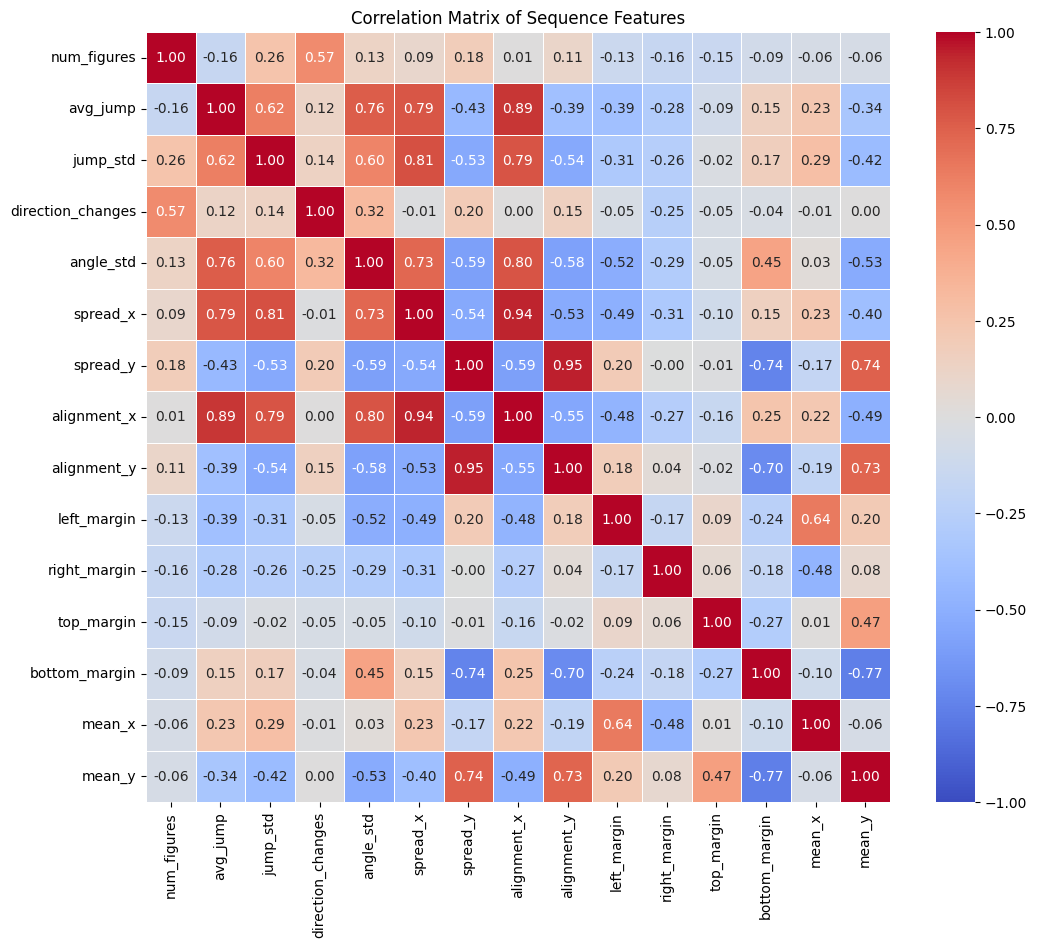

In [7]:
import seaborn as sns
plt.figure(figsize=(12,10))
corr = dataset.corr(numeric_only=True)
sns.heatmap(corr, annot=True , fmt=".2f",      
            cmap='coolwarm', 
            linewidths=0.5,  
            vmin=-1, vmax=1)

plt.title('Correlation Matrix of Sequence Features')
plt.show()

In [8]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load Dataset
dataset = pd.read_csv("sequence_features_dataset.csv")

# show first rows
print(dataset.head())

# Prepare X and y
# target column
y = dataset["label"]

# remove non-feature columns
X = dataset.drop(columns=["label", "image"])

# show shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

   num_figures    avg_jump    jump_std  direction_changes  angle_std  \
0           10  328.823307  136.156810                  6   0.998791   
1           13  351.926599  218.850411                 10   1.127273   
2           10  254.681118  156.755916                  5   0.776725   
3           11  380.624382  214.517086                  6   1.108930   
4            9  287.918207  131.664274                  4   0.978479   

   spread_x  spread_y  alignment_x  alignment_y  left_margin  right_margin  \
0       606      1401   167.550739   478.282385          309           326   
1       816      1390   206.788089   373.843162          240           185   
2       536      1373   139.885811   434.687888          185           520   
3       781      1150   244.186996   381.724188          238           222   
4       830      1018   257.122587   326.145843          125           286   

   top_margin  bottom_margin      mean_x      mean_y                  label  \
0         168      

In [9]:
# Build Random Forest Model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train Model
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [10]:
# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("\nAccuracy:")
print(accuracy)


Accuracy:
0.5


In [11]:
# Classification Report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        predictions
    )
)


Classification Report:

                       precision    recall  f1-score   support

    Confused Sequence       0.00      0.00      0.00         2
Disorganized Sequence       0.50      0.78      0.61         9
       Fixed Sequence       0.00      0.00      0.00         2
   Organized Sequence       0.67      0.40      0.50         5

             accuracy                           0.50        18
            macro avg       0.29      0.29      0.28        18
         weighted avg       0.44      0.50      0.44        18



C:\Users\Marwa Sayed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Marwa Sayed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Marwa Sayed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skl

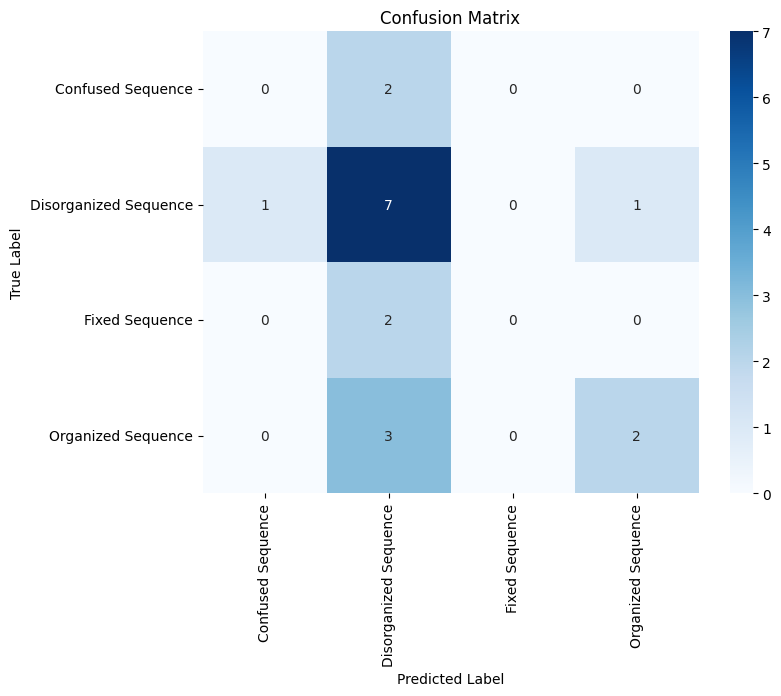

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()
